In [1]:
import os
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ModuleNotFoundError:
    ! pip install seaborn
    import seaborn as sns

#### Functions

In [ ]:
# plot data types
def plot_data_types(df_desc, str_filename='output/data_types.png'):
    # get value counts of dtypes from descriptive statistics
    ser_dtype_counts = df_desc['str_dtype'].value_counts()
    int_total = ser_dtype_counts.sum()
    # plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ser_dtype_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', rot=0)
    ax.set_title('Data Types', fontsize=16)
    ax.set_xlabel('Data Type', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    # annotate bars with count and percent
    for i, int_val in enumerate(ser_dtype_counts):
        flt_pct = int_val / int_total * 100
        ax.text(i, int_val + (ax.get_ylim()[1] * 0.01), f'{int_val}\n({flt_pct:.1f}%)', ha='center', fontsize=11)
    # pad the top so labels don't clip
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [ ]:
# plot proportion missing
def plot_proportion_missing(df_desc, str_filename='output/proportion_missing.png'):
    # filter to columns with missing values
    df_missing = df_desc[df_desc['flt_proportion_missing'] > 0][['str_column', 'flt_proportion_missing']].copy()
    df_missing = df_missing.sort_values('flt_proportion_missing', ascending=True)
    # if no missing values
    if len(df_missing) == 0:
        print('No missing values found.')
        return
    # plot
    fig, ax = plt.subplots(figsize=(10, max(5, len(df_missing) * 0.4)))
    ax.barh(df_missing['str_column'], df_missing['flt_proportion_missing'], color='steelblue', edgecolor='black')
    ax.set_title('Proportion Missing by Column', fontsize=16)
    ax.set_xlabel('Proportion Missing', fontsize=12)
    ax.set_ylabel('Column', fontsize=12)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [4]:
# plot target distribution
def plot_target(df_data, str_target, str_filename='output/target_distribution.png'):
    # value counts
    ser_counts = df_data[str_target].value_counts()
    ser_proportions = df_data[str_target].value_counts(normalize=True)
    # plot
    fig, ax = plt.subplots(figsize=(8, 5))
    ser_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', rot=0)
    ax.set_title('Target Distribution', fontsize=16)
    ax.set_xlabel(str_target, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    # annotate bars with count and proportion
    for i, (int_count, flt_prop) in enumerate(zip(ser_counts, ser_proportions)):
        ax.text(i, int_count + (ax.get_ylim()[1] * 0.01), f'{int_count:,}\n({flt_prop:.2%})', ha='center', fontsize=11)
    # pad the top so labels don't clip
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [ ]:
# descriptive statistics
def descriptive_statistics(df_data):
    df_desc = df_data.describe().T.reset_index()
    df_desc = df_desc.rename(columns={'index': 'str_column'})
    # add data type
    df_desc['str_dtype'] = df_desc['str_column'].apply(lambda x: str(df_data[x].dtype))
    # add unique count
    df_desc['int_n_unique'] = df_desc['str_column'].apply(lambda x: df_data[x].nunique())
    # add proportion missing
    df_desc['flt_proportion_missing'] = df_desc['str_column'].apply(lambda x: df_data[x].isnull().mean())
    # add min and max z-score for outlier detection
    df_desc['flt_min_zscore'] = df_desc['str_column'].apply(
        lambda x: (df_data[x].min() - df_data[x].mean()) / df_data[x].std() if df_data[x].std() > 0 else 0.0)
    df_desc['flt_max_zscore'] = df_desc['str_column'].apply(
        lambda x: (df_data[x].max() - df_data[x].mean()) / df_data[x].std() if df_data[x].std() > 0 else 0.0)
    return df_desc

In [6]:
# plot violin plots
def plot_violin(df_data, str_target, str_filename='output/violin_plots.png'):
    import warnings
    warnings.filterwarnings('ignore')
    # get numeric columns excluding target
    list_numeric_cols = [col for col in df_data.select_dtypes(include=[np.number]).columns if col != str_target]
    int_n_cols = 3
    int_n_rows = int(np.ceil(len(list_numeric_cols) / int_n_cols))
    fig, axes = plt.subplots(int_n_rows, int_n_cols, figsize=(6 * int_n_cols, 4 * int_n_rows))
    axes = axes.flatten() if int_n_rows > 1 else (axes if hasattr(axes, '__iter__') else [axes])
    for i, str_col in enumerate(list_numeric_cols):
        sns.violinplot(data=df_data, x=str_target, y=str_col, ax=axes[i], hue=str_target, palette='muted', legend=False)
        axes[i].set_title(str_col, fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    # hide unused axes
    for j in range(len(list_numeric_cols), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Violin Plots by Target', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300, bbox_inches='tight')
    plt.show()
    warnings.filterwarnings('default')

In [7]:
# plot correlation with target
def plot_correlation_with_target(df_data, str_target, str_filename='output/correlation_with_target.png'):
    # compute correlations with target
    ser_corr = df_data.select_dtypes(include=[np.number]).corr()[str_target].drop(str_target)
    # sort by absolute value
    ser_corr = ser_corr.reindex(ser_corr.abs().sort_values(ascending=True).index)
    # plot
    fig, ax = plt.subplots(figsize=(10, max(5, len(ser_corr) * 0.4)))
    list_colors = ['steelblue' if x >= 0 else 'salmon' for x in ser_corr]
    ser_corr.plot(kind='barh', ax=ax, color=list_colors, edgecolor='black')
    ax.set_title('Correlation with Target', fontsize=16)
    ax.set_xlabel('Correlation', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    ax.axvline(x=0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

#### Constants

In [8]:
# bucket
str_bucket = os.getcwd().split('/')[4].replace('_', '-')
print(f'Bucket: {str_bucket}')

# step
str_step = os.getcwd().split('/')[-1]
print(f'Step: {str_step}')

# s3 path
str_s3_path = f's3://{str_bucket}/00_data_collection/data.csv'
print(f'S3 Path: {str_s3_path}')

# target
str_target = 'default_12m'
print(f'Target: {str_target}')

# output directory
os.makedirs('output', exist_ok=True)

Bucket: credit-risk-claude
Step: 01_eda
S3 Path: s3://credit-risk-claude/00_data_collection/data.csv
Target: default_12m


#### Read Data

In [9]:
# read data
df = pd.read_csv(str_s3_path)

# rows and columns
int_n_rows = df.shape[0]
int_n_cols = df.shape[1]
print(f'Rows: {int_n_rows:,}')
print(f'Columns: {int_n_cols}')

# date range (if date column exists)
list_date_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
if len(list_date_cols) == 0:
    # try to find date-like object columns
    for str_col in df.select_dtypes(include=['object']).columns:
        try:
            pd.to_datetime(df[str_col].head(100))
            list_date_cols.append(str_col)
        except (ValueError, TypeError):
            pass
if len(list_date_cols) > 0:
    str_date_col = list_date_cols[0]
    df[str_date_col] = pd.to_datetime(df[str_date_col])
    print(f'Date Column: {str_date_col}')
    print(f'Date Range: {df[str_date_col].min()} to {df[str_date_col].max()}')

# target mean
flt_target_mean = df[str_target].mean()
print(f'Target Mean: {flt_target_mean:.4f}')

# preview
df.head()

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


Rows: 25,308
Columns: 20
Date Column: origination_date
Date Range: 2022-01-01 00:00:00 to 2024-12-28 00:00:00
Target Mean: 0.1868


/tmp/ipykernel_21626/2623289240.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df[str_col].head(100))
/tmp/ipykernel_21626/2623289240.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df[str_col].head(100))


,loan_id,origination_date,dob,loan_amount,term_months,channel,employment_length_years,stated_income,state,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,default_12m,charged_off_amount,paid_interest_amount,apr
0,5776,2024-03-03,7/10/1981,5690,36,partner,7.33,3115.0,WI,1,636.0,2.0,0.0,0.50,2.0,0,0,0.00,2812.53,0.159
1,1390,2024-05-08,4/3/1998,6230,12,mobile,4.60,11453.0,IL,0,668.0,4.0,2.0,0.38,2.0,0,0,0.00,912.02,0.150
2,882,2024-09-01,8/1/1986,2560,24,mobile,3.94,3159.0,OH,0,640.0,3.0,1.0,0.50,3.0,1,0,0.00,756.67,0.174
3,15629,2024-07-20,9/3/1993,4890,24,mobile,2.12,7527.0,MO,1,722.0,2.0,0.0,0.09,1.0,0,0,0.00,1213.17,0.150
4,21525,2023-02-06,10/16/1977,1450,18,web,8.20,3588.0,AZ,0,530.0,3.0,0.0,0.55,1.0,1,1,631.16,108.46,0.242


#### Descriptive statistics

In [10]:
df_desc = descriptive_statistics(df)
df_desc.to_csv('output/descriptive_statistics.csv', index=False)
df_desc

,str_column,count,mean,min,25%,50%,75%,max,std,int_n_unique,flt_proportion_missing
0,loan_id,25308.0,12495.624822,1.0,6244.75,12492.5,18744.25,25000.0,7215.720431,25000,0.000000
1,origination_date,25308,2023-06-28 13:43:53.854907648,2022-01-01 00:00:00,2022-09-26 00:00:00,2023-06-27 00:00:00,2024-03-26 00:00:00,2024-12-28 00:00:00,NaN,1008,0.000000
2,loan_amount,25308.0,5465.570966,700.0,3490.0,4890.0,6900.0,49930.0,3124.847601,1037,0.000000
3,term_months,25308.0,19.026079,0.0,12.0,18.0,24.0,84.0,9.644642,7,0.000000
4,employment_length_years,24638.0,5.823461,-1.0,2.33,5.07,7.87,68.54,6.760675,1632,0.026474
5,stated_income,24857.0,6015.823832,111.0,3288.0,4965.0,7424.0,100000.0,4588.827436,10118,0.017820
6,has_prior_loans_with_us,25308.0,0.304094,0.0,0.0,0.0,1.0,1.0,0.460032,2,0.000000
7,bureau_score,24765.0,629.714516,300.0,589.0,630.0,671.0,900.0,66.578428,322,0.021456
8,open_trades,24923.0,2.207319,0.0,1.0,2.0,3.0,17.0,1.730472,14,0.015213
9,delinq_12m,25055.0,0.365077,0.0,0.0,0.0,1.0,6.0,0.623303,7,0.009997


#### Data Types

In [ ]:
plot_data_types(df_desc)

#### Missing Values

In [ ]:
plot_proportion_missing(df_desc)

#### Target Variable

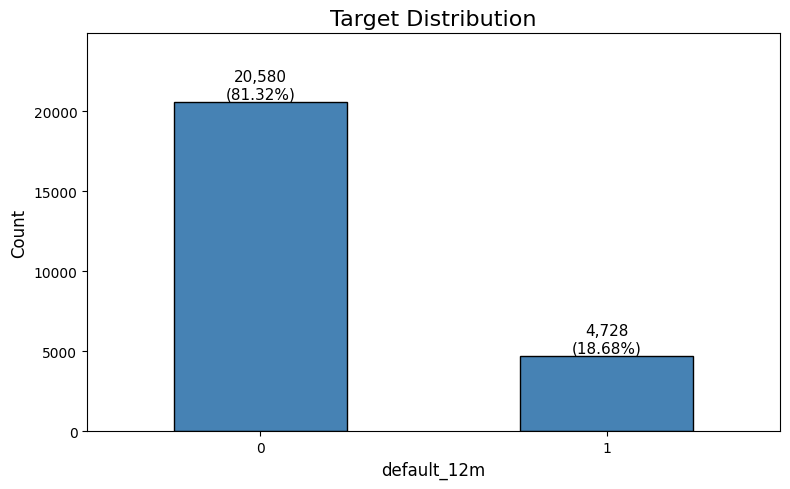

In [13]:
plot_target(df, str_target)

#### Violin Plots

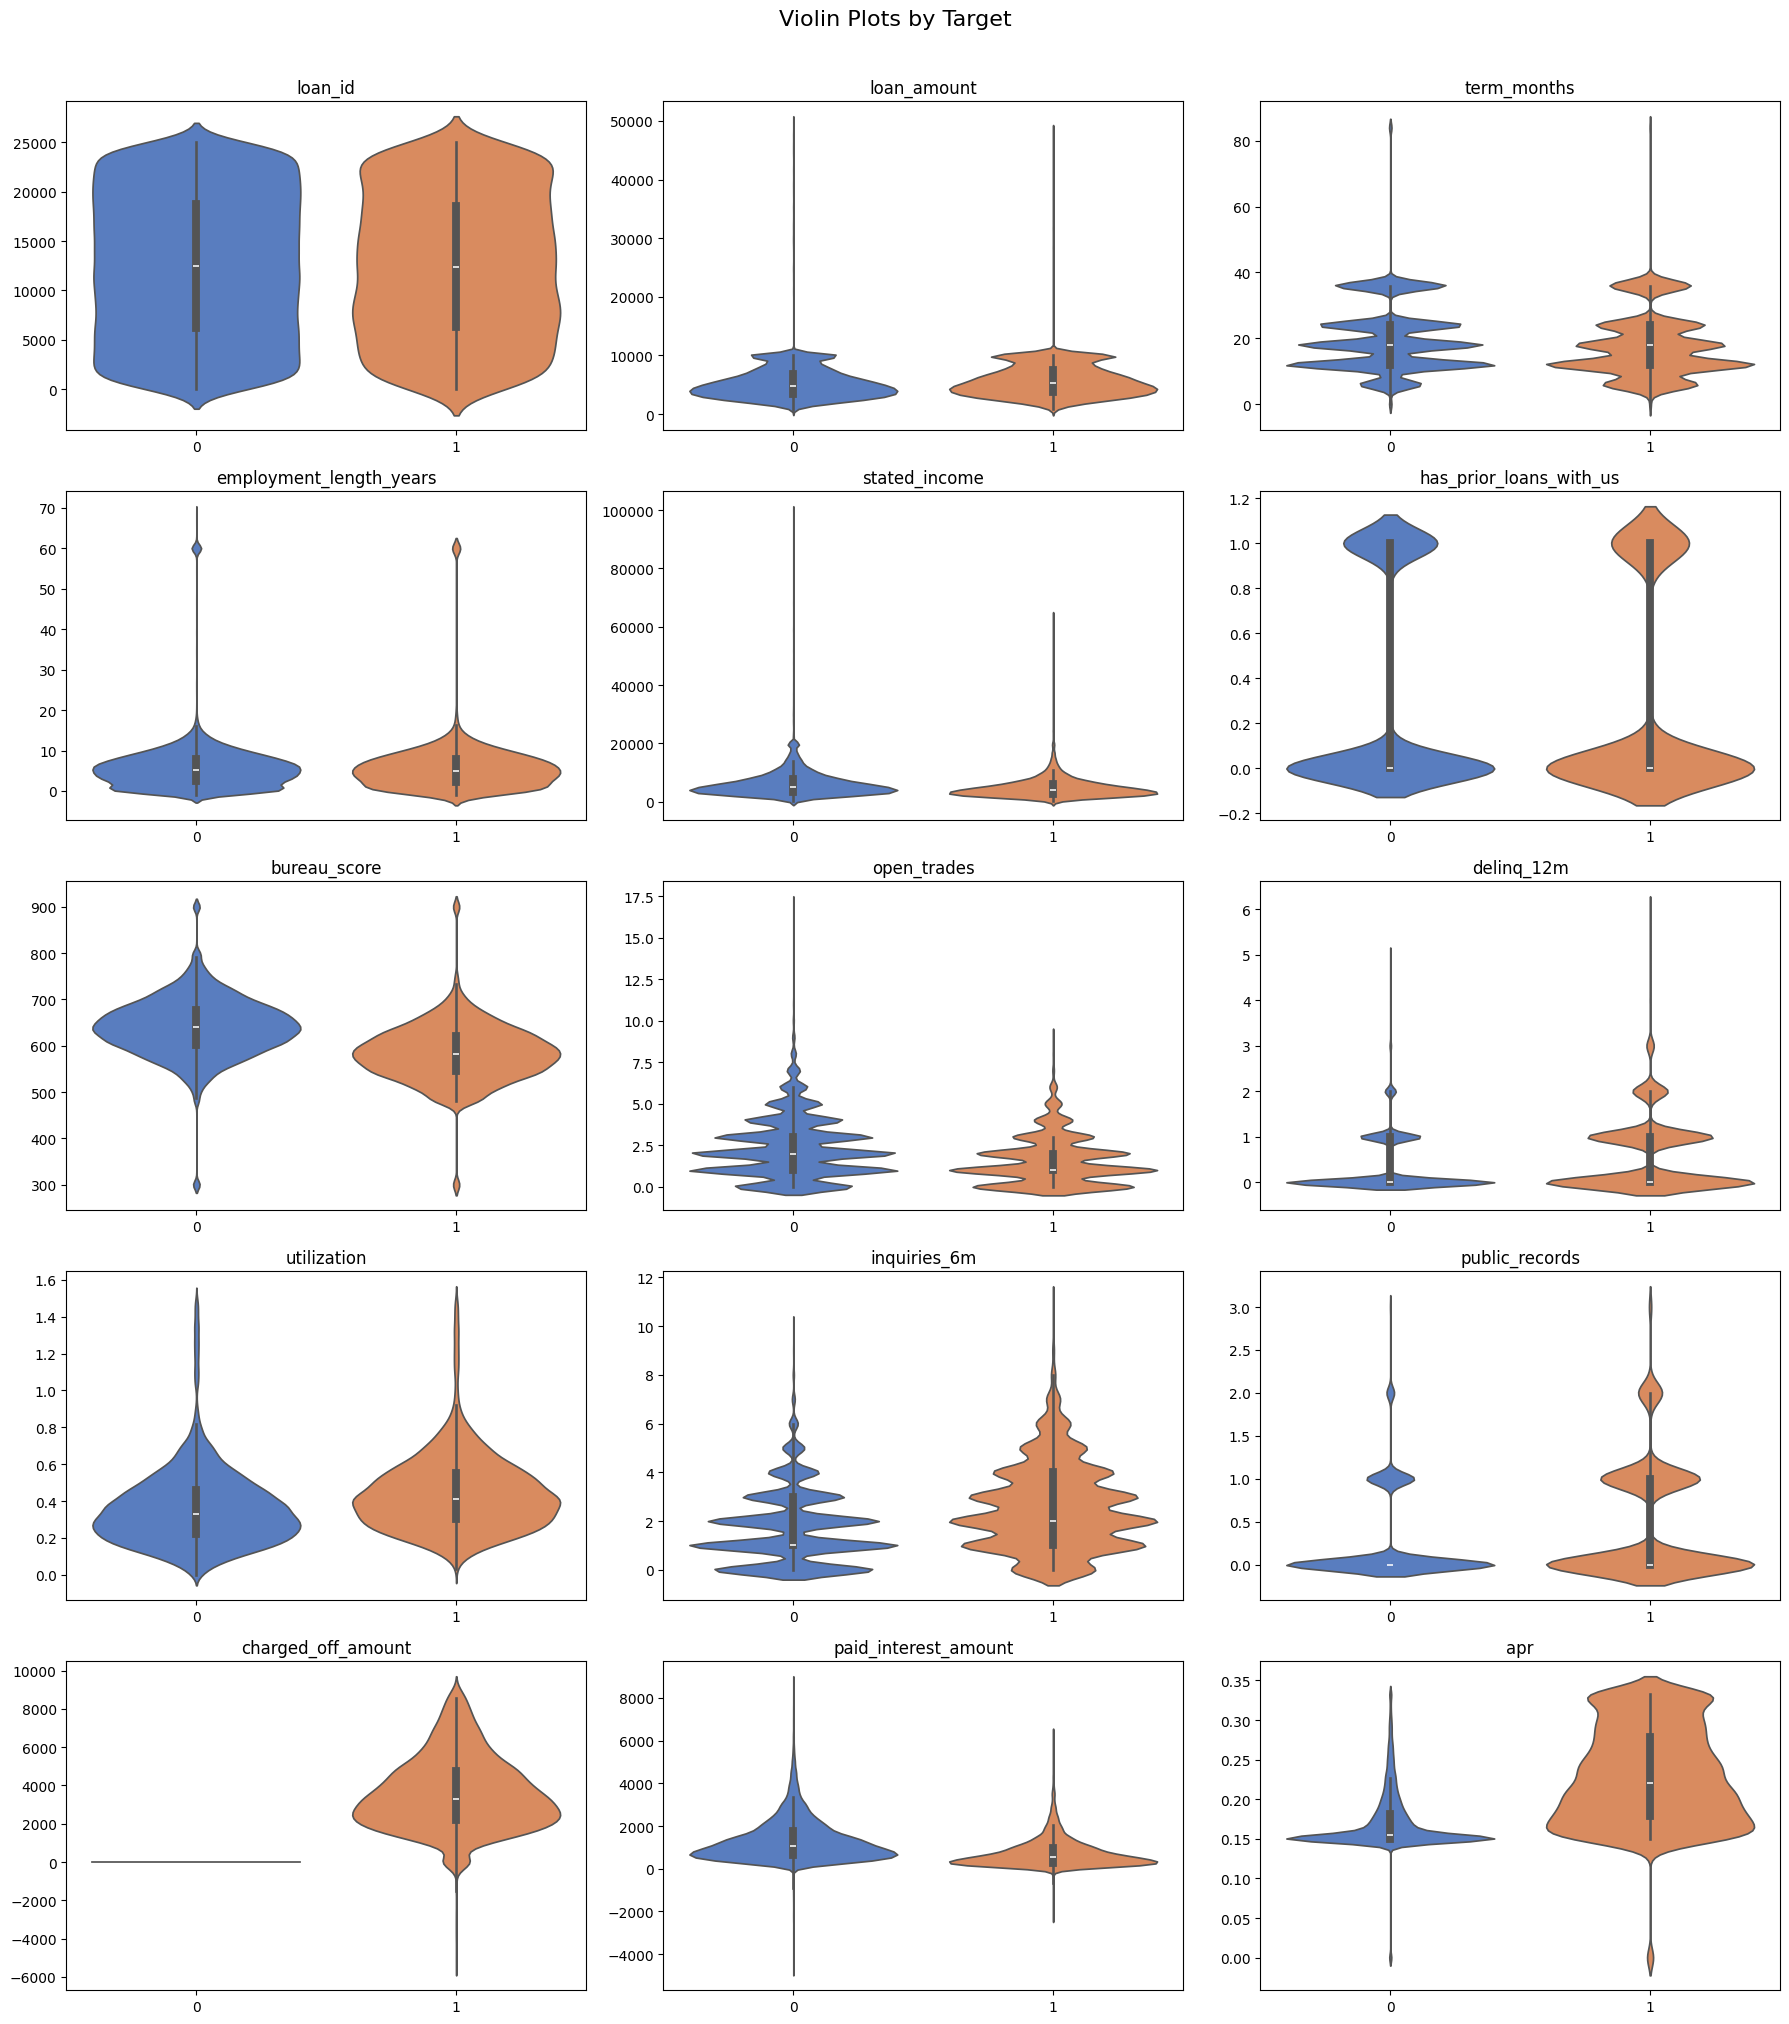

In [14]:
plot_violin(df, str_target)

#### Correlation with Target

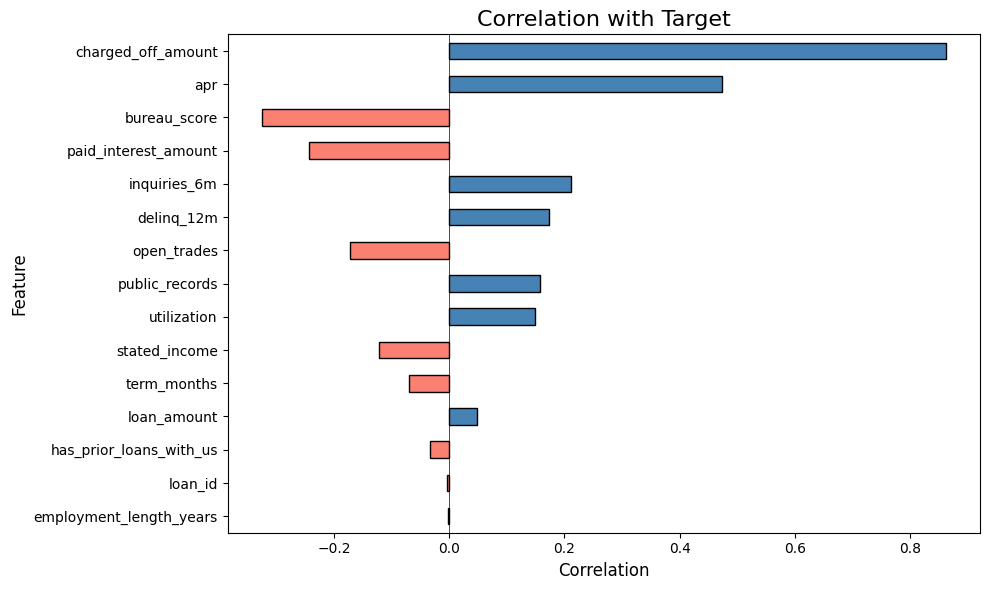

In [15]:
plot_correlation_with_target(df, str_target)